In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from collections import defaultdict

import os
from scipy.sparse import save_npz, load_npz
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as sklearn_split

from surprise import Dataset, Reader, SVD
from surprise.accuracy import rmse

## 1. Исследовательский анализ данных (Exploratory Data Analysis - EDA):

Для рекомендательной системы будем использовать дата-сет с оценками фильмов Netflix (Netflix Prize Data Set).

Т.к. файл с названиями фильмов в качестве разделителя использует запятую и в названии фильмов может быть запятая, то с загрузкой через pd.read_csv могут возникнуть проблемы.<br/>
Но в файле название фильма идет на последней правой позиции. Поэтому прочитаем файл построчно, и последнюю позицию выделим под называние фильма.

In [2]:
with open('movie_titles.txt', 'r', encoding = 'ISO-8859-1') as f:
    lines = f.readlines()

data = []
for line in lines:
    parts = line.strip().split(',')
    movie_id = parts[0]
    year = parts[1]
    name = ','.join(parts[2:])
    data.append([movie_id, year, name])

movies_df = pd.DataFrame(data, columns = ['Movie_Id', 'Year', 'Name'])

Выведем уникальные значения года выхода фильма:

In [3]:
print(sorted(movies_df['Year'].unique()))

['1896', '1909', '1914', '1915', '1916', '1917', '1918', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', 'NULL']


Видно, что есть не значимые строковые значения 'NULL'. Посмотрим, сколько таких значений:

In [4]:
movies_df[movies_df['Year'] == 'NULL']

,Movie_Id,Year,Name
4387,4388,NULL,Ancient Civilizations: Rome and Pompeii
4793,4794,NULL,Ancient Civilizations: Land of the Pharaohs
7240,7241,NULL,Ancient Civilizations: Athens and Greece
10781,10782,NULL,Roti Kapada Aur Makaan
15917,15918,NULL,Hote Hote Pyaar Ho Gaya
16677,16678,NULL,Jimmy Hollywood
17666,17667,NULL,Eros Dance Dhamaka


Видно, что таких всего 7. Заменим их на NA:

In [5]:
movies_df['Year'] = movies_df['Year'].replace('NULL', pd.NA)

Приведем ИД фильма к числовому типу:

In [6]:
movies_df = movies_df.astype({'Movie_Id': 'int32'})
movies_df.head()

,Movie_Id,Year,Name
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


Файл с рейтингами очень большой. Будем читать его пакетно и обрабатывать по 5000 случайным пользователям:

### Шаг 1: читаем рейтинги по chunks, собираем по 5000 случайных пользователям:

In [7]:
all_users = set()

for chunk in pd.read_csv('total_ratings.csv', header=None,
                         names=['Movie_Id', 'Cust_Id', 'Rating', 'Date'],
                         dtype={'Movie_Id': 'int32', 'Cust_Id': 'int32', 'Rating': 'int8'},
                         chunksize=1_000_000):
    all_users.update(chunk['Cust_Id'].unique())

### Шаг 2: выбираем 5000 случайных пользователей

In [8]:
np.random.seed(42)
selected_users = set(np.random.choice(list(all_users), 5000, replace=False))

### Шаг 3: читаем снова, оставляя только их

In [9]:
chunks = []
for chunk in pd.read_csv('total_ratings.csv', header=None,
                         names=['Movie_Id', 'Cust_Id', 'Rating', 'Date'],
                         dtype={'Movie_Id': 'int32', 'Cust_Id': 'int32', 'Rating': 'int8'},
                         parse_dates=['Date'],
                         chunksize=1_000_000):
    filtered = chunk[chunk['Cust_Id'].isin(selected_users)]
    if len(filtered) > 0:
        chunks.append(filtered)

In [10]:
ratings_df = pd.concat(chunks, ignore_index=True)
print(f"Оценок: {len(ratings_df)}, Фильмов: {ratings_df['Movie_Id'].nunique()}")

Оценок: 1085363, Фильмов: 16100


In [11]:
ratings_df.head()

,Movie_Id,Cust_Id,Rating,Date
0,15802,1173712,3,2005-09-15
1,15802,440492,4,2005-05-25
2,15802,691878,3,2005-08-06
3,15802,1329185,4,2005-07-12
4,15802,2460697,5,2005-06-03


Сформируем объединенный датасет из справочника фильмов и их рейтингов:

In [12]:
df = movies_df.merge(ratings_df, how = 'inner', on = 'Movie_Id')
df.head()

,Movie_Id,Year,Name,Cust_Id,Rating,Date
0,1,2003,Dinosaur Planet,573434,4,2004-05-26
1,1,2003,Dinosaur Planet,1137010,4,2004-10-05
2,1,2003,Dinosaur Planet,638824,5,2004-05-19
3,1,2003,Dinosaur Planet,1682104,4,2005-08-30
4,1,2003,Dinosaur Planet,1415954,2,2005-02-14


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1085363 entries, 0 to 1085362
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   Movie_Id  1085363 non-null  int32         
 1   Year      1085360 non-null  str           
 2   Name      1085363 non-null  str           
 3   Cust_Id   1085363 non-null  int32         
 4   Rating    1085363 non-null  int8          
 5   Date      1085363 non-null  datetime64[us]
dtypes: datetime64[us](1), int32(2), int8(1), str(2)
memory usage: 34.2 MB


Видно, что в итоговом датасете отсутствуют пропуски, кроме значений Year, которые мы поменяли

In [14]:
df.describe()

,Movie_Id,Cust_Id,Rating,Date
count,1.085363e+06,1.085363e+06,1.085363e+06,1085363
mean,9.068262e+03,1.310438e+06,3.589030e+00,2004-10-08 02:38:17.637196
min,1.000000e+00,9.210000e+02,1.000000e+00,1999-12-31 00:00:00
25%,4.671500e+03,6.508900e+05,3.000000e+00,2004-04-22 00:00:00
50%,9.051000e+03,1.273019e+06,4.000000e+00,2005-01-19 00:00:00
75%,1.362800e+04,1.993267e+06,4.000000e+00,2005-07-07 00:00:00
max,1.777000e+04,2.649095e+06,5.000000e+00,2005-12-31 00:00:00
std,5.129963e+03,7.685521e+05,1.074874e+00,NaN


Видим, что диапазон рейтингов лежит в пределах от 1 до 5. Выбросов нет.<br/>
Даты установки рейтингов в пределах 2000 - 2006 годов.

Проанализируем распределение рейтингов в наборе данных:

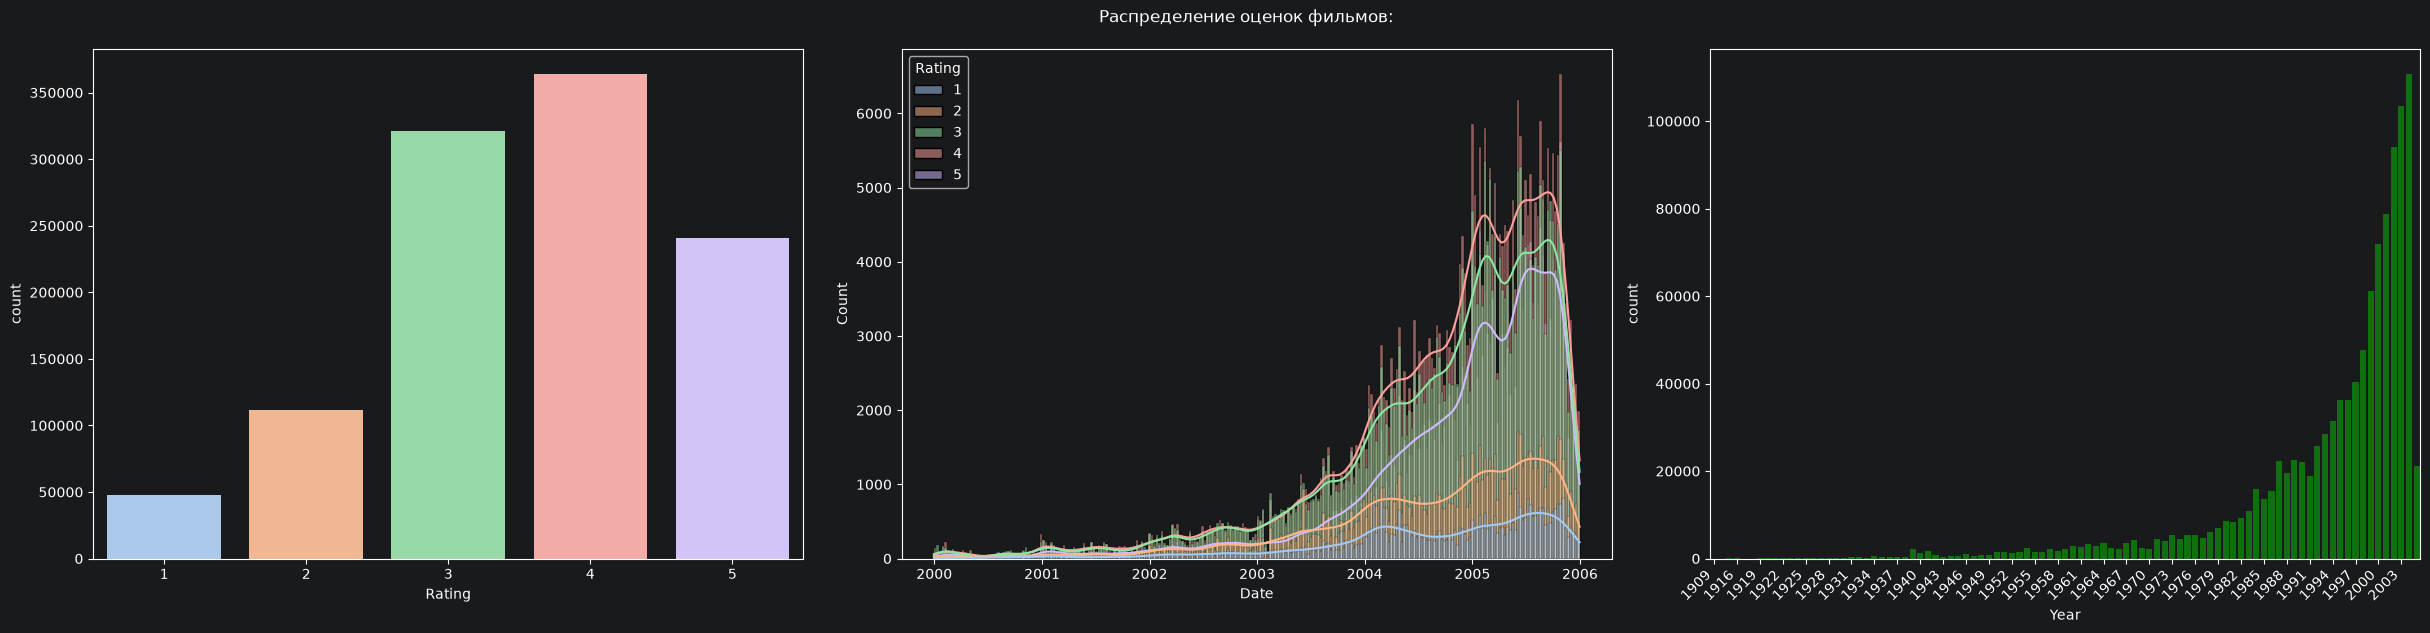

In [15]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 6))
fig.suptitle('Распределение оценок фильмов:')
fig.tight_layout(w_pad = 4.0)

order = sorted(df[~df['Year'].isna()]['Year'].unique())
sns.countplot(data = df, x = 'Rating', hue = 'Rating', palette = 'pastel', legend = False, ax = axes[0])
sns.histplot(data = df, x = 'Date', hue = 'Rating', kde = True, palette = 'pastel', ax = axes[1])
sns.countplot(data = df, x = 'Year', color = 'g', order = order, ax = axes[2])

ticks = axes[2].get_xticks()
labels = [tick.get_text() for tick in axes[2].get_xticklabels()]

step = 3
axes[2].set_xticks(ticks[::step])
axes[2].set_xticklabels(labels[::step], rotation = 45, ha = 'right')

plt.show()

<ul>Из графиков ввидно:
<li>Самая популярная оценка равна 4;</li>
<li>С 2002 года постепенно растет кол-во оценок и достигает пика в 2005;</li>
<li>Самыми популярными являются фильмы 2000-2003 годов выпуска;</li>
</u>

Найдем самые полулярные фильмы с оценками 4 или 5 баллов:

In [16]:
df[df['Rating'] >= 4].groupby(['Movie_Id', 'Name'])['Rating'].count().sort_values(ascending = False).head(10)

Movie_Id  Name                                                  
11283     Forrest Gump                                              1606
16377     The Green Mile                                            1599
1905      Pirates of the Caribbean: The Curse of the Black Pearl    1589
15124     Independence Day                                          1440
11521     Lord of the Rings: The Two Towers                         1427
6287      Pretty Woman                                              1426
4306      The Sixth Sense                                           1421
14550     The Shawshank Redemption: Special Edition                 1421
14313     The Patriot                                               1408
2452      Lord of the Rings: The Fellowship of the Ring             1376
Name: Rating, dtype: int64

Найдем самых активных пользователей:

In [17]:
ratings_df.groupby('Cust_Id')['Rating'].count().sort_values(ascending = False).head(10)

Cust_Id
1559083    3617
1001928    3268
1092521    2997
1489224    2372
1253619    2202
1955660    2166
935732     2133
1764923    2085
1409687    2083
1106280    2055
Name: Rating, dtype: int64

## 2. Подготовка данных (Data Preprocessing):

Сформируем тренировочную и тестовую выборки.

In [18]:
df_train, df_test = sklearn_split(df, test_size = 0.2, random_state = 42)
print(df_train.shape, df_test.shape)

(868290, 6) (217073, 6)


## 3. Разработка моделей рекомендаций:

В справочнике фильмов для контент-ориентированной рекомендации есть всего 2 признака: год выхода фильма и название.<br/>
Вряд ли на основании только этих признаков можно создать качественную модель.

In [19]:
class Hybrid:

    def __init__(self, movies_list, df_train, df_test, k = 10, text_column = 'Feature', precompute_path = 'precomputed/'):
        '''
        Инициализация объекта
        :param movies_list: Справочник фильмов
        :param df_train: Обучающая выборка
        :param df_test: Проверочная выборка
        :param k: Количество рекомендаций для пользователя
        '''

        self.movies_df = movies_list
        self.df_train = df_train
        self.df_test = df_test
        self.k = k

        self.precompute_path = precompute_path
        os.makedirs(precompute_path, exist_ok = True)

        self.rmse = 'N/A'

        self._create_tfidf_matrix(text_column)
        self._create_cosine_sim()
        self._init_top_similar()

    ############################################################################################################################
    # Вычисление матрицы схожести

    def _create_tfidf_matrix(self, text_column):

        tfidf_path = self.precompute_path + 'tfidf_matrix.npz'

        if os.path.exists(tfidf_path):
            print('Загрузка TF-IDF матрицы...')
            self.tfidf_matrix = load_npz(tfidf_path)
        else:
            print('Вычисление TF-IDF матрицы...')
            df_tmp = self.movies_df.copy()
            df_tmp[text_column] = df_tmp['Year'].fillna('') + ' ' + df_tmp['Name']
            tfidf = TfidfVectorizer(stop_words = 'english')
            self.tfidf_matrix = tfidf.fit_transform(df_tmp[text_column].fillna(''))
            save_npz(tfidf_path, self.tfidf_matrix)

        self.movie_ids = self.movies_df['Movie_Id'].tolist()
        # self.movie_idx = {mid: i for i, mid in enumerate(self.movie_ids)}

    def _create_cosine_sim(self):

        cosine_sim_path = self.precompute_path + 'cosine_sim.npy'

        if os.path.exists(cosine_sim_path):
            print('Загрузка матрицы схожести...')
            self.cosine_sim = np.load(cosine_sim_path)
        else:
            print('Вычисление матрицы схожести... (может занять время)')
            self.cosine_sim = cosine_similarity(self.tfidf_matrix, self.tfidf_matrix)
            np.save(cosine_sim_path, self.cosine_sim)
            print(f'Матрица сохранена: {cosine_sim_path}')

    ############################################################################################################################

    def _init_top_similar(self, top_n = 50):

        top_similar_path = self.precompute_path + f'top_{top_n}_similar.pkl'

        if os.path.exists(top_similar_path):
            print(f'Загрузка top_{top_n} похожих фильмов...')
            import pickle
            with open(top_similar_path, 'rb') as f:
                self.top_similar = pickle.load(f)
        else:
            print(f'Вычисление top_{top_n} похожих фильмов...')
            self.top_similar = {}

            for idx, movie_id in enumerate(self.movie_ids):

                similarities = self.cosine_sim[idx]
                top_indices = similarities.argsort()[-top_n - 1:-1][::-1]
                self.top_similar[movie_id] = [self.movie_ids[i] for i in top_indices]

                if (idx + 1) % 5000 == 0:
                    print(f'Обработано {idx + 1} из {len(self.movie_ids)}')

            import pickle
            with open(top_similar_path, 'wb') as f:
                pickle.dump(self.top_similar, f)
        print('Готово')

    ############################################################################################################################

    def _get_popular_movies(self):

        popular_movie_ids = self.df_train[self.df_train['Rating'] >= 4] \
                            .groupby('Movie_Id')['Rating'].count() \
                            .sort_values(ascending = False).head(self.k) \
                            .index.tolist()

        return popular_movie_ids

    ############################################################################################################################

    def _create_position_scores(self, lst):
        l = len(lst) - 1
        return [(elem, (l - i) / l) for i, elem in enumerate(lst)]

    ############################################################################################################################

    def get_baseline_recommends(self):
        '''
        Создание базовых рекомендаций
        :return: рекомендации для всех пользователей из тренировочной выборки
        '''

        top_n = defaultdict(list)

        df_main = pd.concat([self.df_train, self.df_test])
        user_ids = df_main['Cust_Id'].unique()

        popular_movie_ids = self._create_position_scores(self._get_popular_movies())

        for user_id in user_ids:
            top_n[user_id] = popular_movie_ids

        self.baseline_recs = top_n



    ############################################################################################################################

    def get_content_recommends(self):
        '''
        Создание контентных рекомендаций
        :return: рекомендации для всех пользователей из тренировочной выборки
        '''

        top_n = defaultdict(list)

        df_main = pd.concat([self.df_train, self.df_test])
        user_ids = df_main['Cust_Id'].unique()

        for user_id in tqdm(user_ids, desc = 'Вычисление контентных рекомендаций...', ncols = 120):

            user_liked_movies = self.df_train[
                (self.df_train['Cust_Id'] == user_id) & \
                (self.df_train['Rating'] >= 4)
            ]['Movie_Id'].tolist()

            if not user_liked_movies:
                top_n[user_id] = self._create_position_scores(self._get_popular_movies())
                continue

            candidates = {}

            for liked_movie in user_liked_movies:
                for similar_movie in self.top_similar.get(liked_movie, []):
                    candidates[similar_movie] = candidates.get(similar_movie, 0) + 1

            user_rated_movies = self.df_train[self.df_train['Cust_Id'] == user_id]['Movie_Id'].unique()

            for rated_movie in user_rated_movies:
                candidates.pop(rated_movie, None)

            sorted_candidates = sorted(candidates.items(), key = lambda x: x[1], reverse = True)[:self.k]
            sorted_candidates = [mid for mid, _ in sorted_candidates]
            positioned_scores = self._create_position_scores(sorted_candidates)

            top_n[user_id] = positioned_scores

        self.content_recs = top_n

    ############################################################################################################################

    def _create_model(self):

        df_copy = self.df_train[['Cust_Id', 'Movie_Id', 'Rating']].copy()
        df_copy.columns = ['user_id', 'item_id', 'rating']

        reader = Reader(rating_scale=(1, 5))
        data = Dataset.load_from_df(df_copy, reader)

        trainset = data.build_full_trainset()

        model = SVD(n_factors=100, n_epochs=30, lr_all=0.005, reg_all=0.02)
        model.fit(trainset)

        return model

    def _create_testset(self):

        df_copy = self.df_test[['Cust_Id', 'Movie_Id', 'Rating']].copy()
        df_copy.columns = ['user_id', 'item_id', 'rating']

        testset = list(
            zip(
                df_copy['user_id'].values,
                df_copy['item_id'].values,
                df_copy['rating'].values
            )
        )

        return testset

    def get_collaborative_recommends(self):
        '''
        Создание коллаборативных рекомендаций
        :return: рекомендации для всех пользователей из тренировочной выборки
        '''

        top_n = defaultdict(list)

        model = self._create_model()

        testset = self._create_testset()
        predictions = model.test(testset)

        self.rmse = rmse(predictions, verbose = False)

        user_ids = pd.concat([self.df_train, self.df_test])['Cust_Id'].unique()
        all_movies = set(self.df_train['Movie_Id'].unique()) | set(self.df_test['Movie_Id'].unique())

        for user_id in tqdm(user_ids, desc = 'Вычисление коллаборативных рекомендаций...', ncols = 120):

            watched_movies = self.df_train[self.df_train['Cust_Id'] == user_id]['Movie_Id'].unique()
            unwatched_movies = all_movies - set(watched_movies)

            predictions = [(movie_id, model.predict(uid = user_id, iid = movie_id).est) for movie_id in unwatched_movies]
            predictions.sort(key = lambda x: x[1], reverse = True)

            top_n[user_id] = predictions[:self.k]

        self.collab_recs = top_n

    ############################################################################################################################

    def _dict_to_df(self, dict_recs):

        content_list = []

        for uid, user_ratings in dict_recs.items():
            for iid, rating in user_ratings:
                content_list.append([uid, iid, rating])

        return pd.DataFrame(content_list, columns = ['uid', 'iid', 'rating'])

    ############################################################################################################################

    def get_hybrid_recommends(self, w_content = 0.3):
        '''
        Создание гибридных рекомендаций
        :param w_content: вес составляющей контентной рекомендации
        :return: рекомендации для всех пользователей из тренировочной выборки
        '''

        if not hasattr(self, 'content_recs'):
            self.get_content_recommends()

        if not hasattr(self, 'collab_recs'):
            self.get_collaborative_recommends()

        print(f'Вычисление гибридных рекомендаций с весом w_content = {w_content}...')

        content_df = self._dict_to_df(self.content_recs)
        collab_df = self._dict_to_df(self.collab_recs)

        content_df['w_content_rating'] = content_df['rating'] * w_content
        collab_df['w_collab_rating'] = collab_df['rating'] * (1 - w_content)

        union_df = content_df[['uid', 'iid', 'w_content_rating']].merge(right = collab_df[['uid', 'iid', 'w_collab_rating']], how = 'outer', on = ['uid', 'iid']).fillna(0)
        union_df['total_rating'] = union_df['w_content_rating'] + union_df['w_collab_rating']
        union_df = union_df[['uid', 'iid', 'total_rating']]

        hybrid_recs = {}
        for uid, group in union_df.groupby('uid'):
            sorted_group = group.sort_values(by = 'total_rating', ascending = False)
            hybrid_recs[uid] = list(zip(sorted_group['iid'], sorted_group['total_rating']))[:self.k]

        self.hybrid_recs = hybrid_recs

        print('Готово!')


    def get_quality_metrics(self, w_content = 0.3, threshold = 4):
        '''
        Оценка качества рекомендательной системы
        :param w_content: вес составляющей контентной рекомендации
        :param threshold: порог фактической оценки фильма, при котором фильм считается релевантным
        :return: словарь, содержащий: Наименование модели, Наименование оценки, Значение качества
        '''

        if not hasattr(self, 'baseline_recs'): self.get_baseline_recommends()
        if not hasattr(self, 'content_recs'): self.get_content_recommends()
        if not hasattr(self, 'collab_recs'): self.get_collaborative_recommends()
        self.get_hybrid_recommends(w_content = w_content)

        user_real_ratings = defaultdict(dict)

        for user_id, movie_id, rating in zip(
            self.df_test['Cust_Id'],
            self.df_test['Movie_Id'],
            self.df_test['Rating']
        ):
            user_real_ratings[user_id][movie_id] = rating

        recommendations = self.baseline_recs, self.content_recs, self.collab_recs, self.hybrid_recs

        model_types = ['baseline', 'content', 'collaborative', 'hybrid']
        models_dict = dict(zip(model_types, recommendations))

        result = defaultdict(dict)

        for model_type, recommendation in models_dict.items():

            precisions, recalls, aps = [], [], []

            for user_id, rec_list in recommendation.items():
                if user_id not in user_real_ratings:
                    continue

                real_ratings = user_real_ratings[user_id]

                # Precision@k
                relevant_precisions_count = 0
                for movie_id, rating in rec_list[:self.k]:
                    if movie_id in real_ratings and real_ratings[movie_id] >= threshold:
                        relevant_precisions_count += 1

                l = len(rec_list[:self.k])
                precisions.append(relevant_precisions_count / l if l else 0)

                # Recall@k
                relevant_recalls_count = 0
                rec_set = set([m_id for m_id, r in rec_list[:self.k]])
                relevant_recalls_count = sum(
                    1 for movie_id, rating in real_ratings.items()
                    if movie_id in rec_set and rating >= threshold
                )

                l = len([m_id for m_id, r in real_ratings.items() if r >= threshold])
                recalls.append(relevant_recalls_count / l if l else 0)

                # MAP@k
                hits = 0
                ap_sum = 0.0

                for i, (movie_id, r) in enumerate(rec_list[:self.k], start=1):
                    if movie_id in real_ratings and real_ratings[movie_id] >= threshold:
                        hits += 1
                        ap_sum += hits / i

                n_relevant = sum(1 for r in real_ratings.values() if r >= threshold)
                aps.append(ap_sum / min(n_relevant, self.k) if n_relevant else 0.0)

            result[model_type]['precisions'] = round(sum(precisions) / len(precisions), 5) if precisions else 0.0
            result[model_type]['recalls'] = round(sum(recalls) / len(recalls), 5) if recalls else 0.0
            result[model_type]['maps'] = round(sum(aps) / len(aps), 5) if aps else 0.0

        return result

    def tune_weights(self, weight_list = [0.3], threshold = 4):
        '''
        Подбор весов для коллаборативной модели
        :param threshold: порог фактической оценки фильма, при котором фильм считается релевантным
        :return: Набор, содержащий вес и значения метрик
        '''

        result = {}

        for w in weight_list:
            self.get_hybrid_recommends(w_content = w)
            result[w] = self.get_quality_metrics(w_content = w, threshold = threshold)['hybrid']

        return result

Создадим экземпляр класса рекомендательной модели:

In [20]:
%%time
recommend = Hybrid(movies_list = movies_df, df_train = df_train, df_test = df_test)

Загрузка TF-IDF матрицы...
Загрузка матрицы схожести...
Загрузка top_50 похожих фильмов...
Готово
CPU times: user 42.3 ms, sys: 2.13 s, total: 2.17 s
Wall time: 2.6 s


Первоначальная обработка с сохраненем результатов в файлы:<br/>
Wall time: 2.6 s

In [21]:
%%time
recommend = Hybrid(movies_list = movies_df, df_train = df_train, df_test = df_test)

Загрузка TF-IDF матрицы...
Загрузка матрицы схожести...
Загрузка top_50 похожих фильмов...
Готово
CPU times: user 9.85 ms, sys: 1.13 s, total: 1.14 s
Wall time: 1.14 s


Обработка с загрузкой результатов из ранее сохраненных файлов:<br/>
Wall time: 1.14 s

Видим, что предварительное сохранение метрик для контентной модели не привел к значительному росту производительности

### Запустим расчет гибридных рекомендаций, которые также включают в себя заполнение контентных и коллаборативных для объекта:

In [22]:
recommend.get_hybrid_recommends()

Вычисление коллаборативных рекомендаций...: 100%|███████████████████████████████████| 5000/5000 [03:14<00:00, 25.65it/s]


Вычисление гибридных рекомендаций с весом w_content = 0.3...
Готово!


### Попробуем подобрать веса для коллаборативной модели:

In [23]:
hybrid_weight_results = recommend.tune_weights(weight_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

Вычисление гибридных рекомендаций с весом w_content = 0.0...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.0...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.1...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.1...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.2...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.2...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.3...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.3...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.4...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.4...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.5...
Готово!
Вычисление гибридных рекомендаций с весом w_content = 0.5...
Готово!


In [24]:
rows = []
for w, metrics in hybrid_weight_results.items():
    rows.append({
        'weight': w,
        'precision': metrics['precisions'],
        'recall': metrics['recalls'],
        'map': metrics['maps']
    })

weights_df = pd.DataFrame(rows)
weights_df

,weight,precision,recall,map
0,0.0,0.03669,0.01366,0.01659
1,0.1,0.03669,0.01366,0.01673
2,0.2,0.03669,0.01366,0.01674
3,0.3,0.03669,0.01366,0.01678
4,0.4,0.03669,0.01366,0.01679
5,0.5,0.03669,0.01366,0.01679


Метрики _precision_ и _recall_ никак не зависят от коэффициента.<br/>
Влияет только на метрику _map_. И наилучшее качество при значениях коэффициента 0.4 - 0.5.

## 4. Оценка качества моделей:

In [25]:
quality = recommend.get_quality_metrics(w_content = 0.4, threshold = 4)

Вычисление гибридных рекомендаций с весом w_content = 0.4...
Готово!


In [26]:
for model in quality.keys():
    for metric in quality[model].keys():
        print(f'Для модели {model} метрика {metric} равна {round(quality[model][metric], 4)}')
    print('#' * 50)

print(f'Значение RMSE для коллаборативной модели равно {round(recommend.rmse, 4)}')

Для модели baseline метрика precisions равна 0.061
Для модели baseline метрика recalls равна 0.0386
Для модели baseline метрика maps равна 0.0264
##################################################
Для модели content метрика precisions равна 0.0068
Для модели content метрика recalls равна 0.0056
Для модели content метрика maps равна 0.0034
##################################################
Для модели collaborative метрика precisions равна 0.0367
Для модели collaborative метрика recalls равна 0.0137
Для модели collaborative метрика maps равна 0.0165
##################################################
Для модели hybrid метрика precisions равна 0.0367
Для модели hybrid метрика recalls равна 0.0137
Для модели hybrid метрика maps равна 0.0168
##################################################
Значение RMSE для коллаборативной модели равно 0.8948


## 5. Анализ результатов:

| Модель          | Precision@k | Recall@k | MAP@k  | RMSE   |
|-----------------|-------------|----------|--------|--------|
| Базовая         | 0.0061      | 0.0386   | 0.0264 |        |
| Контентная      | 0.0068      | 0.0056   | 0.0034 |        |
| Коллаборативная | 0.0367      | 0.0137   | 0.0165 | 0.8948 |
| Гибридная       | 0.0367      | 0.0137   | 0.0168 |        |

Вывод:<br/>
- Лучше всего показала себя базовая модель (она как нижняя граница на разреженных данных);
- Контентная модель для набора Netflix не подходит, т.к. слишком мало входных параметов для нее (только название и год фильма);
- Доля контентной не значительно влияет на гибридную. Поэтому коэффициент W для контентной можно брать ниже или убирать.

### На примере самого активного пользователя:

Top-10 оценок пользователя на df_train:

In [27]:
df_train[df_train['Cust_Id'] == 1559083].head(10)

,Movie_Id,Year,Name,Cust_Id,Rating,Date
633280,10759,2004,Alexander: Director's Cut,1559083,3,2005-08-04
227937,3946,2001,The Center of the World,1559083,2,2004-01-21
237707,4145,1999,Law & Order: Special Victims Unit: The First Year,1559083,4,2004-01-26
583839,9823,1997,Cadfael: The Raven in the Foregate,1559083,3,2005-07-19
722291,12202,1999,Ray Charles in Concert,1559083,4,2005-09-22
635438,10786,1992,Brother's Keeper: 10th Anniversary Edition,1559083,3,2003-08-10
839032,14122,1981,Lion of the Desert,1559083,3,2004-04-13
39051,696,1996,Last Man Standing,1559083,4,2005-08-25
491849,8117,1982,Pink Floyd: The Wall,1559083,3,2003-08-10
158388,2811,1990,Roger Waters: The Wall: Live in Berlin,1559083,4,2004-04-12


Top-10 оценок пользователя на df_test:

In [28]:
df_test[df_test['Cust_Id'] == 1559083].head(10)

,Movie_Id,Year,Name,Cust_Id,Rating,Date
306640,5237,1995,To Die For,1559083,3,2003-05-10
151321,2690,2000,The Emperor's New Groove,1559083,3,2003-04-28
623729,10561,2005,Ice Princess,1559083,4,2005-09-01
289032,4972,2003,Paycheck,1559083,4,2004-05-22
234869,4109,2000,American Psycho,1559083,3,2004-07-09
984405,16223,1958,Vertigo,1559083,3,2003-04-25
111008,1987,1983,The Dresser,1559083,3,2005-09-28
56617,1066,1978,Superman: The Movie,1559083,3,2004-01-27
355435,5983,1995,Restoration,1559083,3,2004-01-30
140021,2460,1983,Cujo,1559083,3,2004-12-12


Рекомендации для пользователя по контентной модели:

In [29]:
rec_mids = [mid for mid, r in recommend.content_recs[1559083]]
movies_df[movies_df['Movie_Id'].isin(rec_mids)]

,Movie_Id,Year,Name
519,520,2004,E's Otherwise
2989,2990,2004,Go Further
3410,3411,2004,Everyone
5203,5204,2004,The O.C.: Season 2
9196,9197,2004,D.E.B.S.
9409,9410,2004,P.S.
9445,9446,2004,Out of Season
12122,12123,2004,S.I.C.K.
12479,12480,2004,The M.O. of the M.I.
15437,15438,2004,The Off Season


Рекомендации для пользователя по коллаборативной модели:

In [30]:
rec_mids = [mid for mid, r in recommend.collab_recs[1559083]]
movies_df[movies_df['Movie_Id'].isin(rec_mids)]

,Movie_Id,Year,Name
2565,2566,1999,Stargate SG-1: Season 3
3455,3456,2004,Lost: Season 1
4690,4691,2002,Farscape: Season 4
5291,5292,2002,Alias: Season 2
7568,7569,2004,Dead Like Me: Season 2
8291,8292,2004,Star Wars: Clone Wars: Vol. 1
12890,12891,2003,24: Season 3
14380,14381,2001,Law & Order: Criminal Intent: The First Year
14409,14410,2002,Spider-Man
14728,14729,2004,Smallville: Season 4


Рекомендации для пользователя по гибридной модели (совпадают с коллаборативной, т.к. контентная не вносит свой вклад):

In [31]:
rec_mids = [mid for mid, r in recommend.hybrid_recs[1559083]]
movies_df[movies_df['Movie_Id'].isin(rec_mids)]

,Movie_Id,Year,Name
2565,2566,1999,Stargate SG-1: Season 3
3455,3456,2004,Lost: Season 1
4690,4691,2002,Farscape: Season 4
5291,5292,2002,Alias: Season 2
7568,7569,2004,Dead Like Me: Season 2
8291,8292,2004,Star Wars: Clone Wars: Vol. 1
12890,12891,2003,24: Season 3
14380,14381,2001,Law & Order: Criminal Intent: The First Year
14409,14410,2002,Spider-Man
14728,14729,2004,Smallville: Season 4
